# Multi-Asset Portfolio Performance, Risk & Attribution Report

*FINM3422 Assessment 2 — [Group 6 - Yi Chen (Cathy), Caden Rieger, Archer Hanrahan, Sienna Hockaday]*

## 1. Introduction & Methodology

### 1.1 Purpose and Scope

This report analyses the performance, risk, and active-return drivers of a stylised Australian superannuation fund invested across five sleeves: Australian Equities (AUS EQ), International Equities (INTL EQ), Bonds, Real Estate (RE), and Private Equity / Venture Capital (PEVC), over the ten-year period from January 2016 to December 2025. Each sleeve is managed externally and evaluated against a sleeve benchmark, while the total fund is evaluated against an SAA-weighted composite benchmark.

### 1.2 Portfolio Construction

The fund's policy benchmark is constructed using SAA weights, while the implemented portfolio uses Tactical Asset Allocation (TAA) weights. Both weight sets are held constant over the sample period.

| Sleeve | TAA (Portfolio) | SAA (Benchmark) |
|---|---|---|
| AUS EQ | 35% | 40% |
| INTL EQ | 35% | 30% |
| Bonds | 15% | 20% |
| RE | 5% | 5% |
| PEVC | 10% | 5% |

### 1.3 Methodology

All metrics are computed from monthly decimal returns and annualised using the square-root-of-time rule for volatility and geometric compounding for returns.

**Performance and risk metrics.** For each sleeve and the total fund, we compute annualised return, annualised volatility, the Sharpe ratio, the Information Ratio (IR), tracking error (TE), and maximum drawdown (MDD). Returns are annualised geometrically and volatility via the square-root-of-time rule:

$$R_{ann} = \prod_{t=1}^{n}(1+r_t)^{12/n} - 1, \qquad \sigma_{ann} = \sigma_{monthly}\sqrt{12}$$

The Sharpe ratio measures total risk-adjusted excess return, while the Information Ratio measures the efficiency of active management — active return per unit of tracking error:

$$\text{Sharpe} = \frac{R_{ann} - R_{f,ann}}{\sigma_{ann}}, \qquad \text{IR} = \frac{R_P - R_B}{\text{TE}}, \qquad \text{TE} = \sigma(r_P - r_B)\sqrt{12}$$

Maximum drawdown captures the largest peak-to-trough decline in cumulative wealth $W_t = \prod_{s=1}^{t}(1+r_s)$:

$$\text{MDD} = \min_t \frac{W_t - \max_{s \leq t} W_s}{\max_{s \leq t} W_s}$$

**APRA-inspired checks.** The total fund is assessed against four simplified prudential thresholds: a long-run return objective (CPI + 4%), a volatility band, a drawdown limit, and an equity-shock stress scenario. These are educational diagnostics rather than reproductions of actual APRA regulations.

**Brinson attribution.** Active return ($R_P - R_B$) is decomposed at the asset-class level into an allocation effect $A_i = (w_{P,i} - w_{B,i})\,R_{B,i}$, capturing the value added by over- or underweighting each sleeve, and a selection effect $S_i = w_{B,i}(R_{P,i} - R_{B,i})$, capturing manager skill within each sleeve. Effects are computed monthly and aggregated across the sample.

### 1.4 Data and Implementation

The analysis uses the frozen teaching dataset provided in `data/a2_release/`, comprising monthly returns for each manager and benchmark, a monthly risk-free rate proxy, and the SAA weights. All metric and attribution functions are implemented as reusable modules under `src/` (`performance.py`, `apra_checks.py`, `attribution.py`) and called from this notebook to keep the report cell-light and reproducible.

In [1]:
import sys
sys.path.append("../src")  # adjust if your notebook lives elsewhere

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_all, validate
from performance import all_sleeves_summary

# Load everything
data = load_all(data_dir="../data")  # adjust if needed

managers    = data["managers"]
benchmarks  = data["benchmarks"]
rf          = data["rf"]
taa_weights = data["taa_weights"]
saa_weights = data["saa_weights"]

---

## 2. Data Overview

### 2.1 Source and Structure

The analysis uses the frozen FINM3422 teaching dataset, located at `data/a2_release/`. It comprises five manager return series (`managers/`), five benchmark return series (`benchmarks/`), a monthly risk-free rate proxy (`rf_monthly.csv`), and a Strategic Asset Allocation file (`saa_weight.csv`). All return series are reported as **monthly decimal returns** (e.g. 0.0123 = +1.23%) on month-end dates, and all 11 series share an identical, gap-free `DatetimeIndex`.

Manager returns are **synthetic** (artificially generated for teaching purposes). They are designed to behave realistically, capturing plausible relationships between sleeves, benchmarks, and the risk-free rate, but do not correspond to any real-world fund. This caveat is carried into the limitations discussion in section 7.

In [2]:
# Summary statistics for managers and benchmarks (monthly returns)
summary = pd.concat([
    managers.add_suffix("_mgr"),
    benchmarks.add_suffix("_bm")
], axis=1).describe().T

summary[["count", "mean", "std", "min", "max"]].round(4)

,count,mean,std,min,max
AUS_EQ_mgr,120.0,0.0064,0.0409,-0.1931,0.0867
INTL_EQ_mgr,120.0,0.0127,0.0345,-0.0699,0.0803
BONDS_mgr,120.0,0.0026,0.0129,-0.0308,0.0344
RE_mgr,120.0,0.0101,0.0540,-0.2000,0.1568
PEVC_mgr,120.0,0.0086,0.0313,-0.0626,0.0946
AUS_EQ_bm,120.0,0.0056,0.0391,-0.2118,0.0996
INTL_EQ_bm,120.0,0.0115,0.0336,-0.0736,0.0764
BONDS_bm,120.0,0.0017,0.0138,-0.0359,0.0366
RE_bm,120.0,0.0084,0.0604,-0.3500,0.1429
PEVC_bm,120.0,0.0080,0.0330,-0.0751,0.0889


**Table 2.1. Monthly return summary statistics (Jan 2016 – Dec 2025).** All figures are monthly decimal returns. Manager series suffixed `_mgr`; benchmarks suffixed `_bm`.

In [3]:
validate(data)

────────────────────────────────────────────────────────────
DATA LOADER — SANITY CHECK REPORT
────────────────────────────────────────────────────────────

Observations     : 120 months
Date range       : 2016-01-31 to 2025-12-31
Manager sleeves  : ['AUS_EQ', 'INTL_EQ', 'BONDS', 'RE', 'PEVC']
Benchmark sleeves: ['AUS_EQ', 'INTL_EQ', 'BONDS', 'RE', 'PEVC']

Indices aligned  : YES
Missing values   : 0 (should be 0)

TAA weights sum  : 1.0000 OK
SAA weights sum  : 1.0000 OK
Sleeve names     : CONSISTENT

────────────────────────────────────────────────────────────


All checks pass: 120 aligned monthly observations spanning Jan 2016 to Dec 2025, no missing values, both weight sets sum to 1.0, and sleeve names are consistent across managers, benchmarks, and weight dictionaries.

### 2.2 Load and Validate Data

Before running any analysis, we call `data_loader.validate()` to confirm the loaded dataset meets the required standards: index alignment across managers, benchmarks, and the risk-free rate; absence of missing values; weight-set integrity (TAA and SAA each summing to 1.0); and consistent sleeve naming across all weight-aware objects.

### 2.3 Observations

The dataset spans 120 monthly observations across all 10 series, with no missing values and full index alignment between managers, benchmarks, and the risk-free rate.

A first read of the summary statistics reveals patterns consistent with each asset class's known characteristics:

- **International Equities** generated the highest mean monthly return on both the manager (1.27%) and benchmark (1.15%) sides, with moderate dispersion, suggesting a strong risk/reward profile over the sample.
- **Bonds** exhibited by far the lowest volatility (manager std 1.29%, benchmark std 1.38%) and the tightest min–max range, consistent with their role as the fund's defensive allocation.
- **Real Estate** showed the widest dispersion, with a benchmark minimum of −35.0% in a single month, alongside an outsized maximum of +14.3%. The manager's range was meaningfully tighter (−20.0% to +15.7%), an early indication of downside mitigation that we examine more formally in section 3.
- **Australian Equities** showed a similar pattern, with the manager's worst month (−19.3%) modestly less severe than the benchmark's (−21.2%).
- **PE/VC** manager and benchmark statistics are broadly comparable, with a small mean uplift on the manager side (0.86% vs 0.80% monthly) and similar dispersion.

These descriptive statistics motivate the formal performance, risk, and attribution analysis in the sections that follow, where we annualise these monthly figures and examine each sleeve's behaviour relative to its benchmark.

---

## 3. Sleeve-Level Performance

This section evaluates each of the five sleeves against its benchmark, using the metrics defined in section 1.3. Performance is presented in three layers: a summary table comparing managers across all metrics, individual wealth-index charts showing each manager's path against its benchmark, and a cross-sleeve comparison of Sharpe and Information Ratios.

### 3.1 Summary Metrics

In [4]:
# Manager-level summary across all 5 sleeves
sleeves = list(managers.columns)

mgr_summary = all_sleeves_summary(managers, benchmarks, rf, sleeves)

# Format as percentages where appropriate
mgr_summary.style.format({
    "Ann. Return":       "{:.2%}",
    "Ann. Volatility":   "{:.2%}",
    "Sharpe Ratio":      "{:.3f}",
    "Active Return":     "{:.2%}",
    "Tracking Error":    "{:.2%}",
    "Information Ratio": "{:.3f}",
    "Max Drawdown":      "{:.2%}",
})

,Ann. Return,Ann. Volatility,Sharpe Ratio,Active Return,Tracking Error,Information Ratio,Max Drawdown
Sleeve,,,,,,,
AUS_EQ,6.91%,14.16%,0.273,1.05%,4.40%,0.238,-24.63%
INTL_EQ,15.57%,11.96%,1.048,1.47%,2.57%,0.573,-16.49%
BONDS,3.02%,4.46%,-0.005,1.09%,0.94%,1.165,-11.35%
RE,10.84%,18.72%,0.416,1.98%,7.10%,0.278,-28.69%
PEVC,10.24%,10.86%,0.663,0.72%,2.08%,0.347,-11.62%


**Table 3.1 — Manager performance vs benchmark, by sleeve.** Returns, volatility, tracking error, and drawdown are annualised; Sharpe and Information Ratio are dimensionless.

### 3.2 Cross-Sleeve Comparison

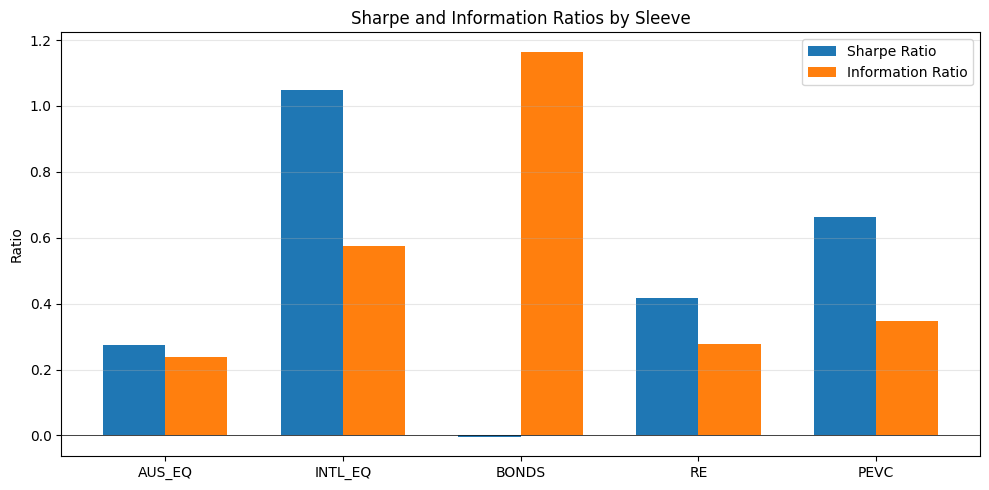

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(sleeves))
width = 0.35

ax.bar(x - width/2, mgr_summary["Sharpe Ratio"],      width, label="Sharpe Ratio")
ax.bar(x + width/2, mgr_summary["Information Ratio"], width, label="Information Ratio")

ax.set_xticks(x)
ax.set_xticklabels(sleeves)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Ratio")
ax.set_title("Sharpe and Information Ratios by Sleeve")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 3.3 Manager vs Benchmark — Wealth Indices

Each chart below tracks the cumulative wealth of $1 invested at the start of the sample period, comparing the manager's path against the corresponding benchmark.

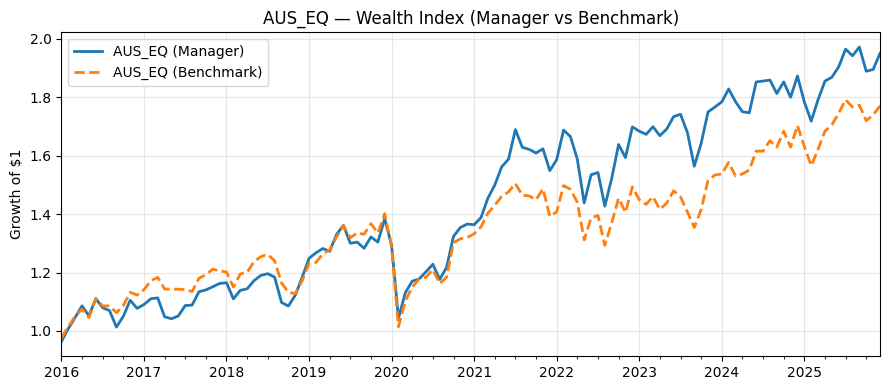

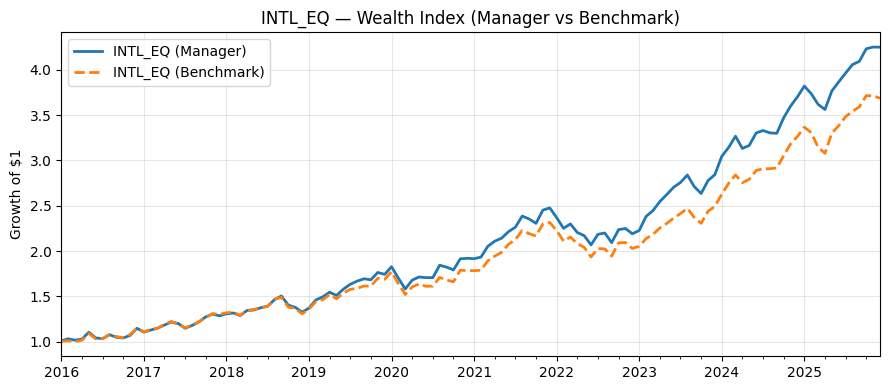

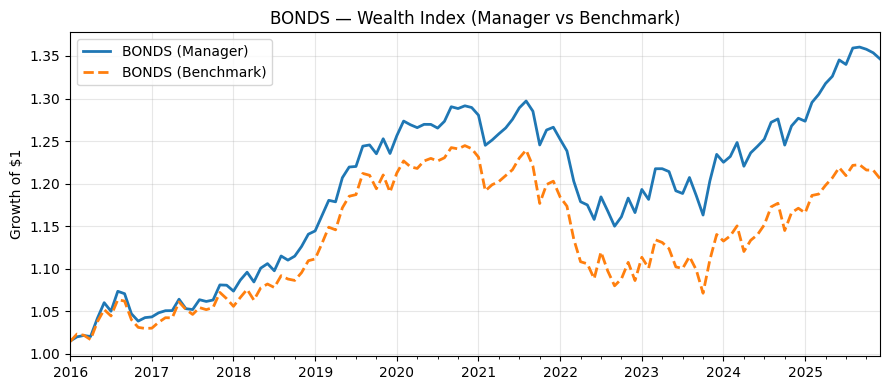

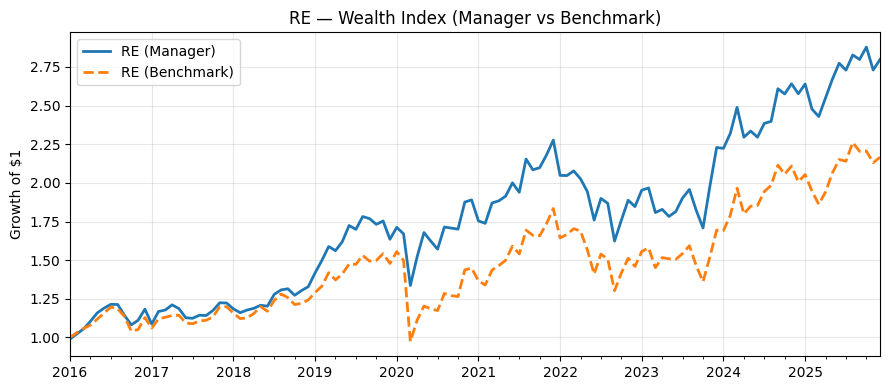

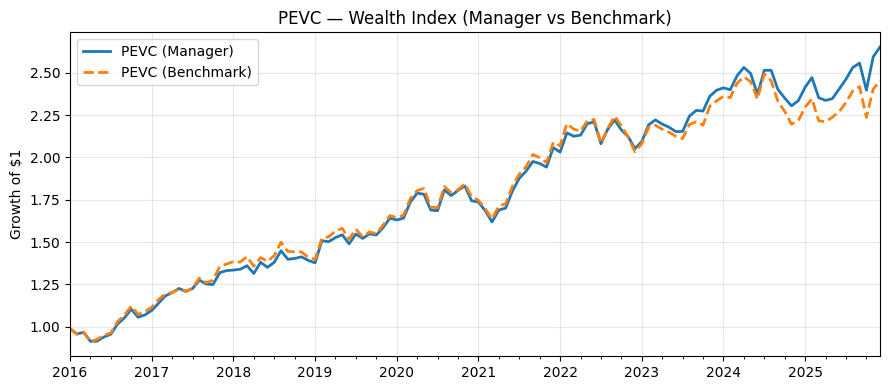

In [6]:
from performance import wealth_index

for sleeve in sleeves:
    fig, ax = plt.subplots(figsize=(9, 4))

    wealth_index(managers[sleeve]).plot(ax=ax, label=f"{sleeve} (Manager)", linewidth=2)
    wealth_index(benchmarks[sleeve]).plot(ax=ax, label=f"{sleeve} (Benchmark)", linewidth=2, linestyle="--")

    ax.set_title(f"{sleeve} — Wealth Index (Manager vs Benchmark)")
    ax.set_ylabel("Growth of $1")
    ax.set_xlabel("")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Figure 3.1 — Sharpe and Information Ratios across sleeves.** Sharpe measures excess return over the risk-free rate per unit of total volatility; Information Ratio measures active return per unit of tracking error.

### 3.4 Discussion



**International Equities is the standout sleeve on every dimension.** It generated the highest annualised return (15.57%), the strongest Sharpe ratio (1.05), and a robust Information Ratio of 0.57, all while running the second-lowest manager volatility (11.96%). This combination of strong absolute and risk-adjusted performance makes it the largest single contributor to fund-level returns over the sample period.

**The Bonds sleeve illustrates why Sharpe and Information Ratio capture different things.** Its Sharpe is effectively zero (−0.005), the bond manager's 3.02% annualised return barely exceeded the risk-free rate over the period, yet it delivered the *highest* Information Ratio of any sleeve (1.17). The interpretation is that the manager added consistent active value relative to the bond benchmark, but the bond asset class itself offered little reward over cash. This is a useful diagnostic: a manager can do their job well even when the asset class disappoints, and a fund relying solely on Sharpe would mis-rank the bond manager's skill.

**Real Estate is the highest-risk sleeve.** It posted the largest tracking error (7.10%), the worst maximum drawdown (−28.69%), and the highest annualised volatility (18.72%). The manager nonetheless generated a respectable 1.98% active return, the largest in absolute terms, but did so by accepting substantially more relative risk than other managers, as reflected in the modest IR of 0.28.

**Australian Equities is the weakest active manager in the equity space.** Despite a similar volatility profile to International Equities, AUS_EQ delivered less than half the annualised return (6.91% vs 15.57%) and a Sharpe of just 0.27. Its IR of 0.24 is also the lowest among the equity-style sleeves, suggesting limited skill relative to the AUS benchmark over the period.

**PE/VC sits in the middle of the pack.** It produced 10.24% return at 10.86% vol, which is the most efficient absolute risk/reward profile after International Equities, but its IR of 0.35 indicates only modest skill relative to its synthetic benchmark.

**Cross-cutting observations.** All five managers beat their benchmarks in active-return terms over the period, but the *quality* of that outperformance varies widely (IRs ranging from 0.24 to 1.17). The fund's largest sleeves by TAA weight (AUS_EQ and INTL_EQ at 35% each) lie at opposite ends of the manager-skill spectrum, which has implications for the attribution analysis in section 6 — selection effects from these two sleeves will likely dominate the active-return decomposition.

---

## 4. Total Fund vs Composite Benchmark

This section evaluates the implemented fund, five managers weighted by Tactical Asset Allocation (TAA), against the composite benchmark, which represents the fund's policy reference: each sleeve's benchmark weighted by Strategic Asset Allocation (SAA). All metrics are constructed from the same monthly returns and weight conventions defined in section 1.

In [7]:
from performance import sleeve_summary

def weighted_return(returns_df, weights_dict):
    """
    Build a portfolio return series from per-sleeve returns and a weights dict.
    Used for both the total fund (TAA × managers) and the composite benchmark (SAA × benchmarks).
    """
    weights = pd.Series(weights_dict)
    return returns_df.mul(weights, axis=1).sum(axis=1)

# Construct fund-level return series
fund_returns       = weighted_return(managers,   taa_weights)
composite_returns  = weighted_return(benchmarks, saa_weights)

# Apply the same per-sleeve summary helper, treating "fund" as a single sleeve
fund_metrics = sleeve_summary(
    sleeve_name="Total Fund",
    portfolio_returns=fund_returns,
    benchmark_returns=composite_returns,
    monthly_rf=rf,
)

# One-row DataFrame to match the section 3 column layout
fund_summary = pd.DataFrame([fund_metrics]).set_index("Sleeve")

fund_summary.style.format({
    "Ann. Return":       "{:.2%}",
    "Ann. Volatility":   "{:.2%}",
    "Sharpe Ratio":      "{:.3f}",
    "Active Return":     "{:.2%}",
    "Tracking Error":    "{:.2%}",
    "Information Ratio": "{:.3f}",
    "Max Drawdown":      "{:.2%}",
})

,Ann. Return,Ann. Volatility,Sharpe Ratio,Active Return,Tracking Error,Information Ratio,Max Drawdown
Sleeve,,,,,,,
Total Fund,10.38%,6.85%,1.070,1.96%,2.04%,0.961,-9.22%


**Table 4.1. Total fund performance and risk metrics vs composite benchmark.** The total fund applies TAA weights to manager returns; the composite benchmark applies SAA weights to benchmark returns. Active metrics are computed against the composite benchmark.

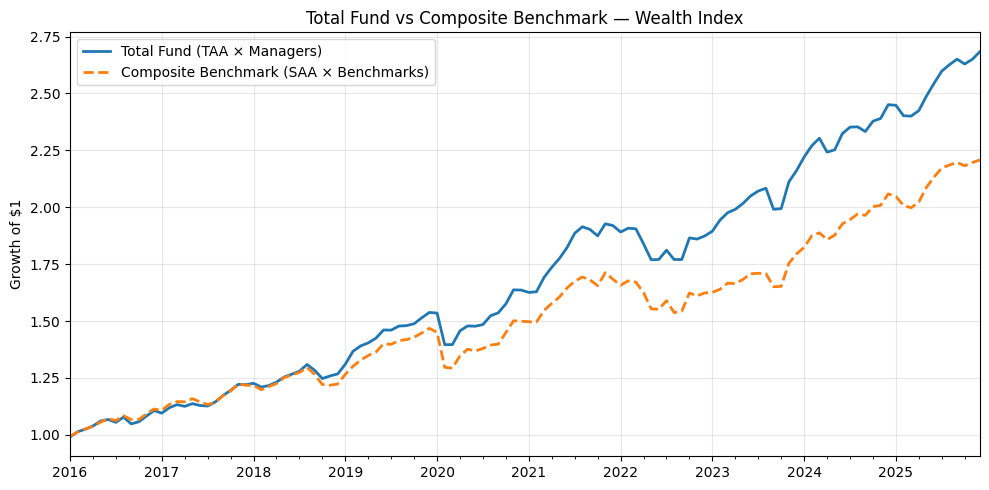

In [8]:
from performance import wealth_index

fig, ax = plt.subplots(figsize=(10, 5))

wealth_index(fund_returns).plot(
    ax=ax, label="Total Fund (TAA × Managers)", linewidth=2
)
wealth_index(composite_returns).plot(
    ax=ax, label="Composite Benchmark (SAA × Benchmarks)", linewidth=2, linestyle="--"
)

ax.set_title("Total Fund vs Composite Benchmark — Wealth Index")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 4.1. Wealth index of the total fund and composite benchmark.** Both series start at $1 in January 2016 and grow with the cumulative product of monthly returns.

### 4.1 Discussion

**Headline result.** The total fund delivered an annualised return of 10.38% at 6.85% volatility, producing a Sharpe ratio of 1.07, comparable to the strongest sleeve (International Equities at 1.05) but achieved with substantially lower volatility through diversification. Against the composite benchmark, the fund generated 1.96% of annualised active return at 2.04% tracking error, yielding an Information Ratio of 0.96. This combination of strong absolute and risk-adjusted performance, alongside efficient active management, is a positive read at the total-fund level.

**Diversification is doing real work.** No individual sleeve achieved this combination of high Sharpe and contained volatility. International Equities reached a similar Sharpe but at 11.96% volatility, which is nearly double the fund's 6.85%. The fund's maximum drawdown of −9.22% is also materially better than any individual sleeve (the next-best was BONDS at −11.35%, RE the worst at −28.69%), indicating that the fund's exposure to volatile sleeves like Real Estate is being effectively offset by the defensive allocation to bonds and the diversification across geographies.

**The wealth-index trajectory shows two distinct phases.** From January 2016 to roughly mid-2021, the fund and composite benchmark track closely, with the fund modestly ahead. After 2021, the fund's wealth path pulls progressively away from the benchmark, ending the period at approximately 2.70× starting capital versus 2.20× for the composite, a cumulative outperformance of roughly 50 percentage points over the ten-year window. This separation in the second half of the sample is consistent with the fund's positive Information Ratio: active management is compounding visibly through time rather than averaging out.

**Tactical positioning matches the manager-skill profile.** The fund overweights INTL_EQ (35% TAA vs 30% SAA) and PE/VC (10% vs 5%) while underweighting AUS_EQ (35% vs 40%) and BONDS (15% vs 20%). Given the section 3 finding that International Equities is the standout performer and Australian Equities is the weakest active manager, these tilts appear directionally well-positioned. The attribution analysis in section 6 will quantify whether the active return came primarily from these allocation tilts or from manager selection within sleeves.

---

## 5. APRA-Inspired Performance & Risk Checks

This section applies a small set of supervisory-style diagnostics to the total fund. The checks are inspired by APRA's prudential framework but are simplified for educational purposes — they are not intended to reproduce regulatory practice. Five checks are applied:

- **Long-run return objective** — the annualised total fund return is compared against a target of CPI + 4% (≈ 6% p.a., assuming a long-run CPI of ~2%, per the Reader §5.2).
- **Volatility band** — the annualised total fund volatility is compared against a notional upper bound of 12%, consistent with the Reader's "balanced" risk profile.
- **Maximum drawdown threshold** — the worst peak-to-trough decline in the fund's wealth index is compared against a −25% supervisory limit.
- **Stress scenario A — Equity crash** — a one-month adverse shock of −20% is applied to AUS_EQ and INTL_EQ on top of a baseline month, following the Reader's stylised stress test (§5.5). The resulting portfolio loss is compared against a −15% threshold.
- **Stress scenario B — Bond yield spike** — a +150bps yield shock is approximated as −5% on bonds and REITs, with mild equity and PE/VC effects (−2% each). The resulting portfolio loss is compared against the same −15% threshold.

For both stress scenarios, the shock is applied on top of a "typical" baseline month — defined as each sleeve's median monthly return over the sample — rather than a worst-observed or zero-return month. This reflects the supervisory question "given normal market conditions, what does an adverse event do to the fund?", and avoids the double-counting that arises from layering a shock on top of an already-extreme month.

A check is flagged "Pass" when the actual value clears the threshold in the appropriate direction.

### 5.1 Supervisory Checks Summary

In [9]:
from apra_checks import run_apra_checks

apra_results = run_apra_checks(data)

apra_results.style.format({
    "Actual":    "{:.2%}",
    "Threshold": "{:.2%}",
})

,Check,Actual,Threshold,Pass
0,Long-run return objective,10.38%,6.00%,True
1,Volatility limit,6.85%,12.00%,True
2,Maximum drawdown,-9.22%,-25.00%,True
3,Stress scenario A (Equity crash),-12.82%,-15.00%,True
4,Stress scenario B (Bond yield spike),-1.42%,-15.00%,True


**Table 5.1. Total fund performance and risk vs supervisory thresholds.** Stress scenarios apply the specified shock on top of a median-return baseline month, per the Reader §5.5 framework. Pass/Fail reflects whether the actual value clears the threshold in the prudentially appropriate direction (returns ≥ target; volatility ≤ limit; drawdown and shock-loss ≥ threshold, since both are negative).

### 5.2 Drawdown Timeline

The drawdown chart visualises the cumulative peak-to-trough decline of the fund's wealth index over time, alongside the −25% supervisory threshold. Drawdown periods correspond to episodes where the fund is below its prior peak; the depth of each trough indicates the severity of the loss before recovery.

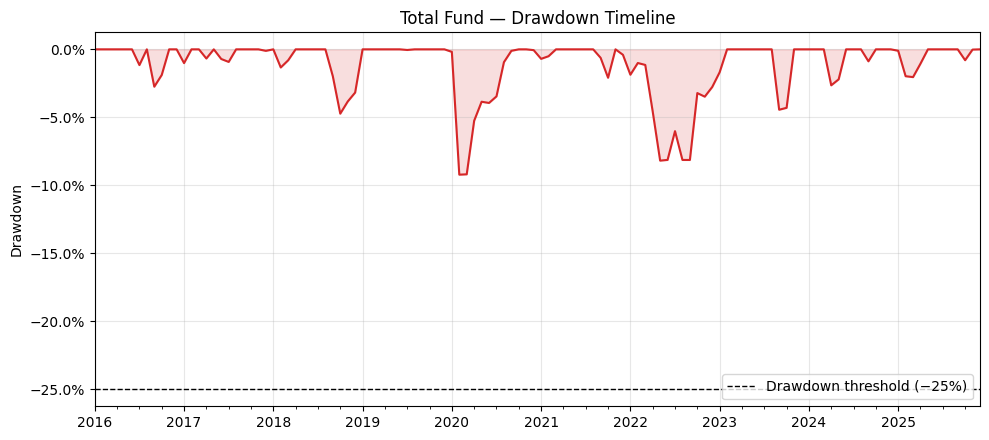

In [10]:
# Drawdown timeline — uses the fund_returns series already constructed in section 4
fund_wealth   = (1 + fund_returns).cumprod()
rolling_peak  = fund_wealth.cummax()
fund_drawdown = (fund_wealth - rolling_peak) / rolling_peak

fig, ax = plt.subplots(figsize=(10, 4.5))
fund_drawdown.plot(ax=ax, linewidth=1.5, color="C3")
ax.axhline(-0.25, linestyle="--", color="black", linewidth=1, label="Drawdown threshold (−25%)")
ax.fill_between(fund_drawdown.index, fund_drawdown, 0, color="C3", alpha=0.15)
ax.set_title("Total Fund — Drawdown Timeline")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 5.1. Total fund drawdown profile vs supervisory threshold.** The shaded region depicts the cumulative below-peak loss at each point in time; the dashed line marks the −25% drawdown threshold.

### 5.3 Rolling Volatility

The 12-month rolling volatility chart shows how the fund's annualised return dispersion evolves through time, alongside the 12% supervisory volatility band. Periods where the rolling estimate approaches or breaches the band warrant supervisory attention even when the full-sample average remains within bounds.

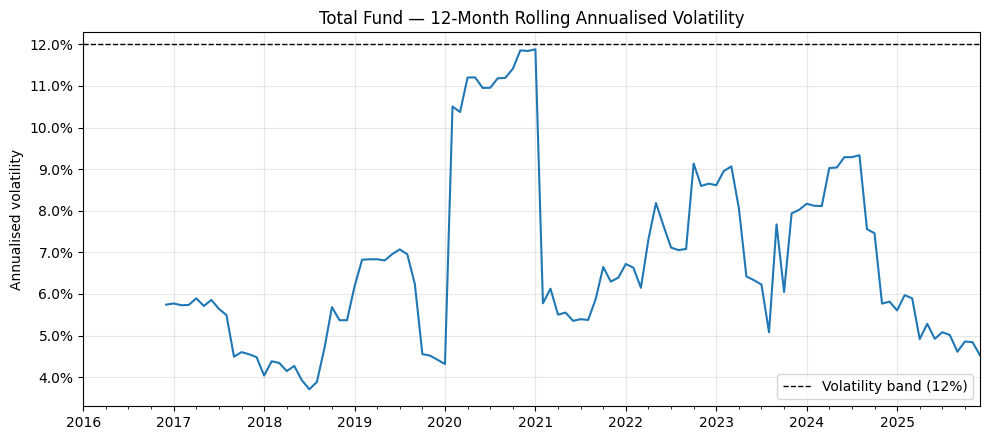

In [11]:
# Rolling 12-month annualised volatility
rolling_vol = fund_returns.rolling(12).std() * np.sqrt(12)

fig, ax = plt.subplots(figsize=(10, 4.5))
rolling_vol.plot(ax=ax, linewidth=1.5, color="C0")
ax.axhline(0.12, linestyle="--", color="black", linewidth=1, label="Volatility band (12%)")
ax.set_title("Total Fund — 12-Month Rolling Annualised Volatility")
ax.set_ylabel("Annualised volatility")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 5.2. Total fund 12-month rolling annualised volatility.** Each point reflects the volatility of the fund's monthly returns over the prior 12 months, scaled by √12. The dashed line marks the 12% supervisory band.

### 5.4 Discussion

**All five checks pass.** The fund clears the long-run return objective (10.38% vs 6.00% target), operates well within the volatility band (6.85% vs 12% limit), stays comfortably inside the drawdown threshold (−9.22% vs −25% limit), and absorbs both stylised stress scenarios within the −15% loss tolerance. The supervisory read at the average level is clean: this is a fund delivering its return objective without breaching prudential risk limits.

**Scenario A is the closest call of any check.** A −20% one-month equity shock applied on top of a typical (median-return) month produces a fund loss of −12.82% — clearing the −15% threshold by just over two percentage points. This narrow margin reflects the fund's 70% TAA exposure to equities (35% AUS_EQ + 35% INTL_EQ), which is the largest single driver of one-month tail risk. A more severe shock (e.g. −25% to equities, in line with March 2020 magnitudes for some markets) or a more conservative threshold would push this scenario into a fail. The result is therefore a "pass with monitoring" rather than a comfortable pass, and the fund's growth tilt is structurally close to the band under equity-led stress.

**Scenario B clears comfortably.** A +150bps bond yield spike (approximated as −5% to bonds and REITs, −2% to equities and PE/VC) produces only a −1.42% portfolio loss. The fund's relatively small fixed-income allocation (15% TAA, below the 20% SAA) limits its sensitivity to a duration-driven selloff, and the modest cross-asset effects don't compound into a meaningful loss. From a supervisory standpoint, this fund is more vulnerable to equity dislocations than to rate shocks — consistent with its growth-tilted positioning.

**Methodology note: the choice of baseline month materially affects the stress-scenario reading.** We applied each shock on top of a median-return baseline, representing a "typical" month. Two alternative baselines were considered and rejected. Applying the shock on top of the fund's *worst observed month* (March 2020) would double-count tail risk, combining a real equity dislocation with an additional simulated one, and produced a Scenario A loss of −26.35% in earlier iterations. Applying the shock to a *zero-return baseline* would isolate the shock cleanly but discard the realism of normal market noise. The median baseline strikes a balance: it asks "given ordinary market conditions, how does the fund absorb an adverse event?", which is what supervisory stress testing is conceptually asking.

**The drawdown profile shows three distinct stress episodes.** The deepest drawdown of −9.22% occurred during the March 2020 COVID-19 dislocation, recovering to its prior peak within roughly six months. A second episode of approximately −8% appears in mid-2022, consistent with the global rate-hike cycle. A smaller −5% drawdown is visible in late 2018, likely related to Fed tightening and global trade tensions. None breaches the −25% supervisory threshold, but the 2020 and 2022 episodes do indicate genuine market-stress exposure rather than a sample period dominated by quiet markets.

**The rolling volatility chart reveals the most important nuance the full-sample metrics obscure.** While the fund's overall annualised volatility of 6.85% sits comfortably below the 12% band, the 12-month rolling estimate spikes to approximately 11.9% during 2020 and early 2021 — within 0.1 percentage points of the supervisory limit. Interpreted strictly, the fund operated at nearly double its long-run risk level for roughly a year, and was a single bad month away from breaching the band on a rolling basis. Full-sample averages mask this kind of time-varying risk concentration, and rolling diagnostics are the appropriate tool for surfacing it.

**Overall supervisory read.** The fund's long-run return generation is strong, drawdown experience has been managed effectively, and average risk profile sits well inside policy bounds. All five checks pass under our chosen methodology. The two genuine watch-points are (i) that Scenario A clears the stress threshold by only two percentage points, the fund's growth tilt leaves it structurally exposed to equity dislocations, and (ii) that the rolling-volatility profile occasionally approached the band even when the average did not. Neither finding overturns the conclusions of section 4, but both argue for ongoing monitoring of tail-risk diagnostics rather than reliance on full-sample averages alone.